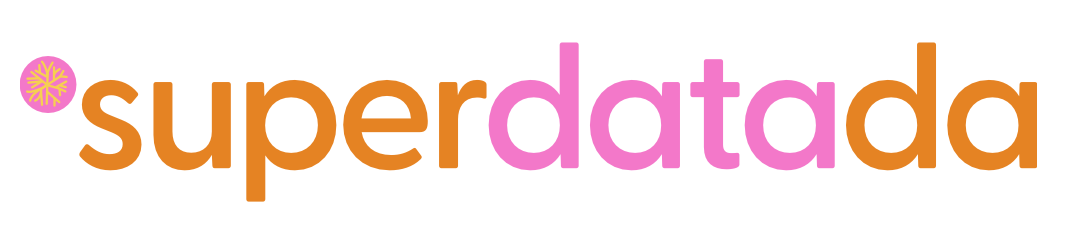

# 💭 ¿Sigue vivo el American Dream... o ya se fue a dormir?

¿Todavía se puede alcanzar el famoso *"Sueño Americano"*?  
¿O ya es solo eso: un sueño? 🥲

Para averiguarlo, analizamos **4 pilares clave** que lo sostienen (o lo sostenían... 👀):

1️⃣ Acceso a la educación 📚 con deudas estudiantiles que ni en sueños pagarías 💰

2️⃣ Vivienda asequible 🏠 cuando divides la renta entre 20 roomies 

3️⃣ Estabilidad económica 🤹‍♀️ trabajos precarios, cero seguridad social y una pizca de gasto desmedido 👩‍💻

4️⃣ Movilidad social 🚀⬇️ pasar de un estrato social a otro es prácticamente imposible (los ricos más ricos 💎 y los pobres más pobres 🍞)


Con los pilares de **Vivienda** y **Estabilidad económica**, hicimos lo que mejor sabemos hacer:  
convertir datos en **gráficas irresistibles con Plotly** 📊🔥

¡La **PESADIYANKEE** es real!

# 1. Librerías ⚙️

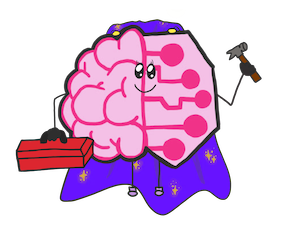

In [ ]:
import pdfplumber
import re
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.io as pio
import numpy as np

# 2. Pilar: Vivienda 🏠

## 💰 Ingresos

Para analizar la **evolución de los ingresos en EE.UU.**, tomamos como referencia los datos históricos de ingresos medianos y promedio, desglosados por grupo racial y origen hispano.

📥 Puedes descargar el dataset original desde la fuente oficial del censo:  
[United States Census Bureau – Table H-5: Race and Hispanic Origin of Householder — Households by Median and Mean Income](https://www.census.gov/data/tables/time-series/demo/income-poverty/historical-income-households.html)

Estos datos nos permiten visualizar **cómo han cambiado los ingresos a lo largo del tiempo**, y nos dan pistas importantes sobre el acceso (o la falta de acceso) al tan mencionado *"Sueño Americano"*.

In [35]:
# Cargar dataset
ing = pd.read_csv("data/h05.csv")

# Renombrar columnas para mayor claridad
ing.rename(columns={"ALL": "year", "MEDIAN_INCOME": "median_income"}, inplace=True)

# Extraer solo los primeros 4 dígitos del año y convertir a entero
ing["year"] = ing["year"].str.extract(r"(\d{4})").astype(int)

# Limpiar valores numéricos: eliminar comas y convertir a entero
ing["median_income"] = ing["median_income"].str.replace(",", "").astype(int)

# Vista previa
ing.head()

,year,median_income
0,2023,80610
1,2022,74580
2,2021,70780
3,2020,68010
4,2019,68700


## 🏡 Precio de Casas

Para analizar la evolución del precio de la vivienda en Estados Unidos, usamos el indicador:

**Median Sales Price of Houses Sold for the United States (MSPUS)**  
Fuente: [Federal Reserve Economic Data (FRED)](https://fred.stlouisfed.org/series/MSPUS)

Este indicador representa el **precio mediano de venta de casas** a nivel nacional, una medida clave para entender la accesibilidad (o inaccesibilidad) del mercado inmobiliario.

¿Por qué importa esto?  
Porque si el precio de una casa sube más rápido que los ingresos… bueno, el sueño americano empieza a parecer más una pesadilla inmobiliaria. 😬🏚️


In [36]:
# Cargar dataset de precios medianos de casas
pr = pd.read_csv("data/MSPUS.csv")

# Convertir columna 'observation_date' a tipo datetime
pr["observation_date"] = pd.to_datetime(pr["observation_date"])

# Extraer el año de la fecha
pr["year"] = pr["observation_date"].dt.year

# Calcular el promedio anual del precio mediano de casas
pr = pr.groupby("year")["MSPUS"].mean().reset_index()

# Mostrar las primeras filas del DataFrame procesado
pr.head()

,year,MSPUS
0,1963,18050.0
1,1964,18925.0
2,1965,20125.0
3,1966,21500.0
4,1967,22750.0


## 📊 Múltiplo mediano

El **múltiplo mediano** es una métrica clave que relaciona el precio de las viviendas con los ingresos medios de los hogares.  
Este indicador nos ayuda a entender cuánto “multiplica” el precio de una casa respecto al ingreso anual promedio, mostrando así la accesibilidad real del mercado inmobiliario.

Mientras más alto sea el múltiplo, más difícil resulta para las personas comprar una vivienda sin endeudarse significativamente.


In [6]:
# Unir los dos DataFrames por la columna 'year'
mm = pd.merge(ing, pr, on="year", how="inner")
# Calcular el múltiplo mediano
mm["med_ratio"] = mm["MSPUS"] / mm["median_income"]
mm.head()

,year,median_income,MSPUS,med_ratio
0,2023,80610,426525.0,5.291217
1,2022,74580,432950.0,5.805176
2,2021,70780,383000.0,5.411133
3,2020,68010,328150.0,4.825026
4,2019,68700,320250.0,4.661572


## Gráfica con Plotly ✨

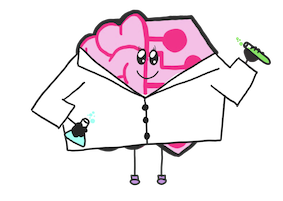

In [ ]:
# Cálculo del tamaño máximo deseado para las burbujas
max_bubble_size = 40
sizeref = 2 * mm["med_ratio"].max() / (max_bubble_size**2)

fig = go.Figure()

# 🎭 Fondo tenebroso en tonos púrpura oscuro
fondo_colores = ["#330033", "#1a1a2e", "#2a0033", "#1e0033"]
for i, color in enumerate(fondo_colores):
    fig.add_shape(
        type="rect",
        x0=mm["year"].min() + i * (mm["year"].max() - mm["year"].min()) / 4,
        x1=mm["year"].min() + (i + 1) * (mm["year"].max() - mm["year"].min()) / 4,
        y0=0,
        y1=mm["MSPUS"].max() * 1.1,
        yref="y",
        xref="x",
        fillcolor=color,
        opacity=0.15,
        layer="below",
        line_width=0,
    )

# Línea de ingreso medio
fig.add_trace(
    go.Scatter(
        x=mm["year"],
        y=mm["median_income"],
        mode="lines+markers",
        name="💵 Ingreso Medio",
        line=dict(color="#0A5218"),
    )
)

# Línea de precio de vivienda
fig.add_trace(
    go.Scatter(
        x=mm["year"],
        y=mm["MSPUS"],
        mode="lines+markers",
        name="🏠 Precio de Vivienda",
        line=dict(color="#FF0000", dash="dash"),
    )
)

# Burbujas: ratio precio/ingreso
fig.add_trace(
    go.Scatter(
        x=mm["year"],
        y=mm["med_ratio"],
        mode="markers",
        name="",
        yaxis="y2",
        marker=dict(
            size=mm["med_ratio"],
            sizemode="area",
            sizeref=sizeref,
            sizemin=4,
            color=mm["med_ratio"],
            coloraxis="coloraxis",
            line=dict(width=0),
        ),
        hovertemplate="Año: %{x}<br>☠️ Múltiplo Mediano: %{y:.2f}<extra></extra>",
    )
)

# Línea horizontal: límite de asequibilidad
fig.add_shape(
    type="line",
    x0=mm["year"].min(),
    x1=mm["year"].max(),
    y0=3,
    y1=3,
    yref="y2",
    line=dict(color="#AAAAAA", dash="dot"),
)

fig.add_annotation(
    x=2022,
    y=3,
    yref="y2",
    text="⚰️ Límite de asequibilidad",
    showarrow=True,
    arrowhead=1,
    font=dict(color="white", size=20),
)

# Layout creepy morado + sin líneas cero
fig.update_layout(
    title=dict(
        text="<b>Nivel de Asequibilidad</b>",
        x=0.5,
        xanchor="center",
        font=dict(size=34, family="Courier New", color="white"),
    ),
    font=dict(family="Courier New", size=20, color="white"),
    plot_bgcolor="#1a001a",  # 👈 fondo morado oscuro
    paper_bgcolor="#1a001a",
    xaxis=dict(
        title=dict(text="", font=dict(size=24, color="white")),
        color="white",
        gridcolor="#333333",
        zeroline=False,  # 👈 quita línea en x=0
    ),
    yaxis=dict(
        title=dict(text="💵 Dólares (USD)", font=dict(color="white", size=24)),
        tickprefix="$",
        color="white",
        gridcolor="#333333",
        zeroline=False,  # 👈 quita línea en y=0
        range=[mm["median_income"].min() * 0.95, mm["MSPUS"].max() * 1.05],
    ),
    yaxis2=dict(
        title=dict(text="☠️ Múltiplo Mediano", font=dict(color="white", size=24)),
        overlaying="y",
        side="right",
        showgrid=False,
        zeroline=False,  # 👈 también aquí
        rangemode="tozero",
        color="white",
    ),
    coloraxis=dict(
        colorscale=[
            [0.0, "#006400"],
            [0.3, "#8B008B"],
            [0.6, "#FF4500"],
            [1.0, "#8B0000"],
        ],
        colorbar=dict(
            title=dict(text="💀 Asequibilidad", font=dict(color="white", size=22)),
            orientation="h",
            x=0.50,
            y=-0.4,
            tickvals=[3, 4, 5],
            ticktext=[
                "Asequible 🟢",
                "Seriamente inasequible 🫣",
                "Severamente Inasequible 😱",
            ],
            tickfont=dict(color="white", size=18),
        ),
        cmin=2.5,
        cmax=6,
    ),
    legend=dict(
        orientation="h",
        y=1.1,
        x=0.5,
        xanchor="center",
        font=dict(color="white", size=18),
    ),
    margin=dict(t=80, b=120),
)

fig.show()

# 3. Pilar: Estabilidad Financiera 💵

## 💸 Gastos

Obtuvimos datos sobre el gasto promedio que hacen los estadounidenses para calcular cuál debería ser el sueldo ideal para alcanzar el famoso **Sueño Americano**.  

Es decir, a partir de cuánto gastan en promedio, estimamos el ingreso que realmente deberían estar recibiendo para vivir cómodamente y cumplir ese ideal.

📥 Descarga en: [Bureau of Labor Statistics -Consumer Expenditure Survey - Data](https://www.bls.gov/cex/tables/top-line-means.htm)



In [58]:
archivos_1 = [
    "data/cu-all-multi-year-1984-1991.pdf",
    "data/cu-all-multi-year-1992-1999.pdf",
    "data/cu-all-multi-year-2000-2005.pdf",
]

df_gastos_1 = pd.DataFrame()

for archivo in archivos_1:
    print(f"Procesando {archivo}...")

    # Extraer año inicial del nombre del archivo
    match_year = re.search(r"(\d{4})", archivo)
    anio_inicio = int(match_year.group(1)) if match_year else 1984

    with pdfplumber.open(archivo) as pdf:
        texto_completo = ""
        for page in pdf.pages:
            texto_pagina = page.extract_text()
            if texto_pagina:
                texto_completo += texto_pagina + "\n"

    match = re.search(r"Average annual expenditures:\s*\n?(.*?)\n", texto_completo)

    if match:
        valores_raw = match.group(1)
        valores = re.findall(r"\$([\d,]+)", valores_raw)
        valores = [int(v.replace(",", "")) for v in valores]

        anos = list(range(anio_inicio, anio_inicio + len(valores)))

        df_temp = pd.DataFrame(
            {
                "Año": anos,
                "Gasto Anual Promedio": valores,
            }
        )
        # Concatenar: reasignar el resultado
        df_gastos_1 = pd.concat([df_gastos_1, df_temp], ignore_index=True)
    else:
        print("No se encontró la línea de 'Average annual expenditures'")


def extraer_gastos_y_anos(texto: str) -> pd.DataFrame | None:
    """
    Extrae los años y los gastos anuales promedio de un bloque de texto.

    Args:
        texto (str): Texto completo del PDF.

    Returns:
        pd.DataFrame | None: DataFrame con columnas 'Año' y 'Gasto Anual Promedio' o None si falla.
    """
    bloque_datos = None
    bloques = texto.split("\n\n")  # Separar por doble salto de línea

    for bloque in bloques:
        if (
            "Average annual expenditures and characteristics of all consumer unit"
            in bloque
        ):
            bloque_datos = bloque
            break

    if not bloque_datos:
        print("No se encontró el bloque de datos.")
        return None

    linea_gastos = None
    for linea in bloque_datos.split("\n"):
        if linea.strip().startswith(
            "Average annual expenditures...."
        ) or linea.strip().startswith("Average annual expenditures ...."):
            linea_gastos = linea.strip()
            break

    if not linea_gastos:
        print("No se encontró la línea con gastos.")
        return None

    print(linea_gastos)

    anos = []
    for linea in bloque_datos.split("\n"):
        if linea.strip().startswith("Item"):
            anos = re.findall(r"\d{4}", linea)
            anos = [int(a) for a in anos]
            break

    if not anos:
        print("No se encontraron años.")
        return None

    valores_gasto = re.findall(r"\$\d{1,3}(?:,\d{3})*(?:\.\d+)?", linea_gastos)
    if not valores_gasto:
        valores_gasto = re.findall(r"\d{1,3}(?:,\d{3})*(?:\.\d+)?", linea_gastos)

    valores_gasto = [v.replace("$", "").replace(",", "") for v in valores_gasto]

    valores_gasto = [int(float(v)) for v in valores_gasto]

    if len(anos) != len(valores_gasto):
        print(
            f"Error: cantidad de años ({len(anos)}) y valores ({len(valores_gasto)}) no coinciden."
        )
        return None

    df_resultado = pd.DataFrame({"Año": anos, "Gasto Anual Promedio": valores_gasto})
    return df_resultado


archivos_2 = [
    "data/cu-all-multi-year-2006-2012.pdf",
    "data/cu-all-multi-year-2013-2020.pdf",
    "data/cu-all-multi-year-2021-2022.pdf",
]

for archivo in archivos_2:
    with pdfplumber.open(archivo) as pdf:
        texto_completo = ""
        for page in pdf.pages:
            texto_pagina = page.extract_text()
            if texto_pagina:
                texto_completo += texto_pagina + "\n"

    df_gastos_2 = extraer_gastos_y_anos(texto_completo)
    if df_gastos_2 is not None:
        df_gastos = pd.concat([df_gastos_1, df_gastos_2], ignore_index=True)
df_gastos.head()

Procesando data/cu-all-multi-year-1984-1991.pdf...
Procesando data/cu-all-multi-year-1992-1999.pdf...
Procesando data/cu-all-multi-year-2000-2005.pdf...
Average annual expenditures........................... $48,400 $49,638 $50,486 $49,067 $48,109 $49,705 $51,442
Average annual expenditures .............................................. $51,100 $53,495 $55,978 $57,311 $60,060 $61,224 $63,036 $61,334
Average annual expenditures .......................................................................................................................................................... $66,928 $72,967


,Año,Gasto Anual Promedio
0,1984,21975
1,1985,23490
2,1986,23866
3,1987,24414
4,1988,25892


## Ingresos 💵

Los datos de ingresos mínimos reales en EE. UU. provienen de [Economic Policy Institute (EPI)](https://data.epi.org/minimum_wage/minimum_wage_levels/line/year/national/real_minimum_wage_2024/overall?timeStart=1938-01-01&timeEnd=2024-01-01&dateString=2024-01-01&highlightedLines=overall).



In [57]:
sueldos = pd.read_csv("data/Minimum.csv")
sueldos["Año"] = pd.to_datetime(sueldos["date"]).dt.year
sueldos["Salario_Diario"] = sueldos["Overall"] * 8

df_sueldos = pd.merge(
    df_gastos, sueldos[["Año", "Salario_Diario"]], on="Año", how="left"
)
df_sueldos["Salario_Necesario"] = df_sueldos["Gasto Anual Promedio"] / 260

df_sueldos.head()

,Año,Gasto Anual Promedio,Salario_Diario,Salario_Necesario
0,1984,21975,72.239876,84.519231
1,1985,23490,69.864275,90.346154
2,1986,23866,68.734118,91.792308
3,1987,24414,66.485349,93.900000
4,1988,25892,64.114129,99.584615


## Gráfica con Plotly ✨

In [ ]:
# ==== Parámetros ====
LABEL_STEP = 3  # etiquetas cada 2 años + el último
LABEL_FONT_SIZE = 20
STEP = 1  # 1 año por frame
DREAM_LABEL_YSHIFT_USD = 10  # offset vertical para etiquetas Dream

# Rango del eje Y (más alto = 350)
Y_MIN = 50
Y_MAX = 400
ANNO_Y = Y_MAX - 5  # altura de las anotaciones de brecha (en unidades de USD)

# ==== Datos ====
df_cost = df_sueldos.sort_values("Año").copy()
years = df_sueldos["Año"].to_list()
wage = df_sueldos["Salario_Diario"].to_list()
dream = df_sueldos["Salario_Necesario"].to_list()

# ==== Estilo ====
deep_space = "#302255"
nebula = "#806BB8"
grid_purple = "#614E70"
title_purple = "#F7F3FA"
text_purple = "#E9D5FF"
c_wage = "#227511"
c_dream = "#E90765"
c_brecha = "rgba(192,132,252,0.20)"


def money(v):
    return f"${v:.0f}"


# ==== Figura base ====
fig = go.Figure(
    layout=dict(
        paper_bgcolor=deep_space,
        plot_bgcolor=nebula,
        font=dict(family="Courier New, monospace", color=text_purple, size=18),
        title=dict(
            text="¿Alcanza para el sueño americano?",
            font=dict(size=35, color=title_purple),
            x=0.5,
            xanchor="center",
        ),
        xaxis=dict(title="Año", gridcolor="rgba(126,53,199,0.25)", zeroline=False),
        yaxis=dict(
            title="USD",
            tickprefix="$ ",
            separatethousands=True,
            gridcolor="rgba(126,53,199,0.25)",
            zeroline=False,
            range=[Y_MIN, Y_MAX],
        ),  # ← rango más alto
        # ↓ Leyenda un poquito más abajo para no tocar el título
        legend=dict(
            orientation="h",
            x=0.5,
            xanchor="center",
            y=1.06,
            yanchor="bottom",
            bgcolor="rgba(0,0,0,0)",
            font=dict(size=24),
        ),
        # Márgenes compactos → área de trazo más grande
        margin=dict(l=40, r=30, t=175, b=40),
        hovermode="x unified",
        hoverlabel=dict(namelength=-1),
        uirevision="keep",
        transition=dict(duration=0),
    )
)

# [0] Línea Salario mínimo (animada)
fig.add_trace(
    go.Scatter(
        name="Salario mínimo",
        mode="lines+markers",
        line=dict(color=c_wage, width=2.5),
        marker=dict(size=7, line=dict(width=1.5, color="rgba(240,171,252,0.18)")),
        x=[years[0]],
        y=[wage[0]],
        hovertemplate="Año: %{x}<br>Salario mínimo: $%{y:.0f}<extra></extra>",
    )
)
# [1] Línea American Dream (animada)
fig.add_trace(
    go.Scatter(
        name="Salario para American Dream",
        mode="lines+markers",
        line=dict(color=c_dream, width=2.5),
        marker=dict(size=6, line=dict(width=1.5, color="rgba(240,171,252,0.18)")),
        x=[years[0]],
        y=[dream[0]],
        fill=None,
        hovertemplate="Año: %{x}<br>American Dream: $%{y:.0f}<extra></extra>",
    )
)
# [2] Conectores verticales (animados por datos)
fig.add_trace(
    go.Scatter(
        name="Conectores",
        mode="lines",
        line=dict(color="rgba(192,132,252,0.55)", width=2),
        opacity=0.35,
        showlegend=False,
        hoverinfo="skip",
        x=[],
        y=[],
    )
)

# ==== Etiquetas: un trazo por etiqueta; text="" hasta su año ====
label_idxs = [
    k for k in range(len(years)) if (k % LABEL_STEP == 0) or (k == len(years) - 1)
]
wage_lbl_trace, dream_lbl_trace = {}, {}

for k in label_idxs:
    fig.add_trace(
        go.Scatter(
            name=f"lbl_w_{years[k]}",
            x=[years[k]],
            y=[wage[k]],
            mode="text",
            text=[""],
            textposition="top center",
            textfont=dict(size=LABEL_FONT_SIZE),
            showlegend=False,
            hoverinfo="skip",
            cliponaxis=False,
        )
    )
    wage_lbl_trace[k] = len(fig.data) - 1

for k in label_idxs:
    fig.add_trace(
        go.Scatter(
            name=f"lbl_d_{years[k]}",
            x=[years[k]],
            y=[dream[k] + DREAM_LABEL_YSHIFT_USD],  # ↑ subimos las etiquetas Dream
            mode="text",
            text=[""],
            textposition="top center",
            textfont=dict(size=LABEL_FONT_SIZE),
            showlegend=False,
            hoverinfo="skip",
            cliponaxis=False,
        )
    )
    dream_lbl_trace[k] = len(fig.data) - 1


# ==== Helpers ====
def connectors_until(i):
    xs, ys = [], []
    for k in range(i):
        xs += [years[k], years[k], None]
        ys += [wage[k], dream[k], None]
    return xs, ys


# ==== Frames ====
frames, steps = [], []
idxs = list(range(1, len(years) + 1, STEP))
if idxs[-1] != len(years):
    idxs.append(len(years))

# RESET: regresa todo y limpia etiquetas + quita anotaciones
reset_updates, reset_ids = [], []
reset_updates += [go.Scatter(x=[years[0]], y=[wage[0]])]
reset_ids += [0]
reset_updates += [go.Scatter(x=[years[0]], y=[dream[0]], fill=None)]
reset_ids += [1]
reset_updates += [go.Scatter(x=[], y=[])]
reset_ids += [2]
for tid in list(wage_lbl_trace.values()) + list(dream_lbl_trace.values()):
    reset_updates += [go.Scatter(text=[""])]
    reset_ids += [tid]

frames.append(
    go.Frame(
        name="RESET",
        data=reset_updates,
        traces=reset_ids,
        layout=go.Layout(annotations=[]),  # ← limpia las leyendas de brecha
    )
)
steps.append(
    dict(
        label="Inicio",
        method="animate",
        args=[
            ["RESET"],
            dict(
                mode="immediate",
                frame=dict(duration=0, redraw=False),
                transition=dict(duration=0),
            ),
        ],
    )
)

# Años: revela solo la etiqueta nueva del año actual
for i in idxs:
    year_i = years[i - 1]
    updates, ids = [], []
    updates += [go.Scatter(x=years[:i], y=wage[:i])]
    ids += [0]
    updates += [go.Scatter(x=years[:i], y=dream[:i])]
    ids += [1]
    cx, cy = connectors_until(i)
    updates += [go.Scatter(x=cx, y=cy)]
    ids += [2]

    if (i - 1) in wage_lbl_trace:
        updates += [go.Scatter(text=[money(wage[i - 1])])]
        ids += [wage_lbl_trace[i - 1]]
    if (i - 1) in dream_lbl_trace:
        updates += [go.Scatter(text=[money(dream[i - 1])])]
        ids += [dream_lbl_trace[i - 1]]

    frames.append(go.Frame(name=str(year_i), data=updates, traces=ids))
    steps.append(
        dict(
            label=str(year_i),
            method="animate",
            args=[
                [str(year_i)],
                dict(
                    mode="immediate",
                    frame=dict(duration=0, redraw=False),
                    transition=dict(duration=0),
                ),
            ],
        )
    )

# Brecha final: activar área + mostrar leyendas como ANOTACIONES en esquinas
brecha_ini_val = int(dream[0] - wage[0])
brecha_fin_val = int(dream[-1] - wage[-1])

ann_left = dict(
    xref="paper",
    yref="y",
    x=0.02,
    y=ANNO_Y,  # ← y en datos (alto fijo)
    xanchor="left",
    yanchor="top",
    text=f"💲 Brecha inicial: {money(brecha_ini_val)}",
    showarrow=False,
    font=dict(color="#F5D0FE", size=20),
    bgcolor="rgba(18,10,35,0)",
)
ann_right = dict(
    xref="paper",
    yref="y",
    x=0.98,
    y=ANNO_Y,  # ← y en datos (alto fijo)
    xanchor="right",
    yanchor="top",
    text=f"💲 Brecha final: {money(brecha_fin_val)}",
    showarrow=False,
    font=dict(color="#F5D0FE", size=20),
    bgcolor="rgba(18,10,35,0)",
)

final_updates, final_ids = [], []
final_updates += [go.Scatter(x=years, y=wage)]
final_ids += [0]
final_updates += [go.Scatter(x=years, y=dream, fill="tonexty", fillcolor=c_brecha)]
final_ids += [1]
cx_all, cy_all = connectors_until(len(years))
final_updates += [go.Scatter(x=cx_all, y=cy_all)]
final_ids += [2]

frames.append(
    go.Frame(
        name="Brecha",
        data=final_updates,
        traces=final_ids,
        layout=go.Layout(annotations=[ann_left, ann_right]),
    )
)
steps.append(
    dict(
        label="Brecha",
        method="animate",
        args=[
            ["Brecha"],
            dict(
                mode="immediate",
                frame=dict(duration=0, redraw=False),
                transition=dict(duration=120),
            ),
        ],
    )
)

fig.frames = frames

# ==== Controles (arriba; no tapan el eje) ====
play_sequence = ["RESET"] + [str(years[i - 1]) for i in idxs] + ["Brecha"]
fig.update_layout(
    sliders=[
        dict(
            active=0,
            steps=steps,
            transition=dict(duration=0),
            x=0.10,
            xanchor="left",
            len=0.80,
        )
    ],
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.02,
            y=1.42,
            yanchor="top",
            buttons=[
                dict(
                    label="▶ Reproducir",
                    method="animate",
                    args=[
                        play_sequence,
                        dict(
                            fromcurrent=False,
                            frame=dict(duration=260, redraw=False),
                            transition=dict(duration=0),
                            mode="immediate",
                        ),
                    ],
                ),
                dict(
                    label="↺ Reiniciar",
                    method="animate",
                    args=[
                        ["RESET"],
                        dict(
                            fromcurrent=False,
                            frame=dict(duration=0, redraw=False),
                            transition=dict(duration=0),
                            mode="immediate",
                        ),
                    ],
                ),
            ],
        )
    ],
)

# Vignette (debajo de las trazas)
fig.add_shape(
    type="rect",
    xref="paper",
    yref="paper",
    x0=0,
    y0=0,
    x1=1,
    y1=1,
    line=dict(width=0),
    fillcolor="rgba(0,0,0,0.18)",
    layer="below",
)

fig.show()